## Classification Models on (Breast Cancer Wisconsin (Diagnostic) Dataset)

In [207]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set()
import warnings
warnings.filterwarnings("ignore")

In [208]:
# import data set
data = pd.read_csv('data.csv')
cancer = data.copy()

In [209]:
cancer.info() # data general information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [210]:
cancer.isnull().sum() # if data have null values/ handle with SimpleImputer

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [211]:
cancer.duplicated().sum() # if data contain duplicates, uses cancer.drop_duplicates(inplace = True)

np.int64(0)

In [212]:
# saprateing x and y data
x = cancer.iloc[:, 2:].values
y = cancer.iloc[:, 1].values

In [213]:
# Encode the y data
from sklearn.preprocessing import LabelEncoder
encode = LabelEncoder()
y = encode.fit_transform(y)

In [214]:
# split data in to train and test set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y , test_size = 0.2, random_state = 0)

In [215]:
from sklearn.impute import SimpleImputer
# Example: numeric-only X (if x_train/x_test are numeric arrays)
num_imputer = SimpleImputer(strategy='mean')
x_train = num_imputer.fit_transform(x_train)
x_test = num_imputer.transform(x_test)

In [216]:
# feature scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_sctrain = sc.fit_transform(x_train)
x_sctest = sc.transform(x_test)

In [217]:
# create models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression 
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve

classification_models = {
    "LogisticRegression" : LogisticRegression(),
    "DecisionTreeClassifier" : DecisionTreeClassifier(criterion = 'entropy', random_state =0),
    "RandomForestClassifier" : RandomForestClassifier(n_estimators = 20, criterion = 'entropy', random_state =0),
    "XGBClassifier" : XGBClassifier(),
    "LGBMClassifier" : LGBMClassifier()
}

In [218]:
# train, predict and collect metrics
results_cls = {}

for name, model in classification_models.items():
    # fit the model
    if 'LogisticRegression' in name:
        model.fit(x_sctrain, y_train)
        y_pred = model.predict(x_sctest)
        y_prob = model.predict_proba(x_sctest)[:, 1]
    else:
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        y_prob = model.predict_proba(x_test)[:, 1]

    # metrics for model
    report = classification_report(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results_cls[name] = {
        "accuracy": acc,
        "auc": auc,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "report": report
    }
    print(f"{name:<20} -  Accuracy: {acc:.3f}, ROC_AUC: {auc:.3f}")
    print()
    print(report)
        

LogisticRegression   -  Accuracy: 0.965, ROC_AUC: 0.993

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        67
           1       0.96      0.96      0.96        47

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114

DecisionTreeClassifier -  Accuracy: 0.930, ROC_AUC: 0.931

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        67
           1       0.90      0.94      0.92        47

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114

RandomForestClassifier -  Accuracy: 0.974, ROC_AUC: 0.997

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        67
           1       0.98      0.96      0.97        47

    acc

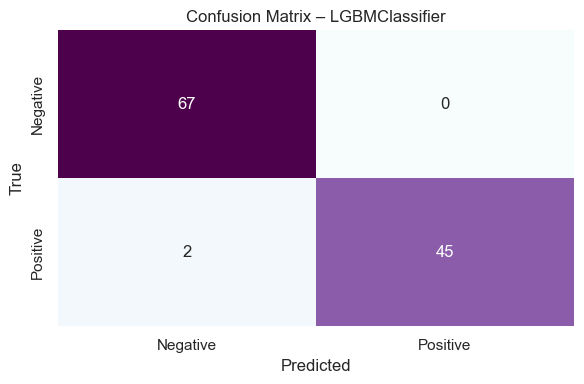

In [219]:
# Confusion matrix for best model

def plot_confusion(y_test, y_pred, title=""):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='BuPu',
                cbar=False, xticklabels=["Negative", "Positive"],
                yticklabels=["Negative", "Positive"])
    plt.title(title)
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

best_name = max(results_cls, key=lambda name: results_cls[name]["accuracy"])
y_pred_best = results_cls[best_name]["y_pred"]
plot_confusion(y_test, y_pred_best, f"Confusion Matrix – {best_name}")

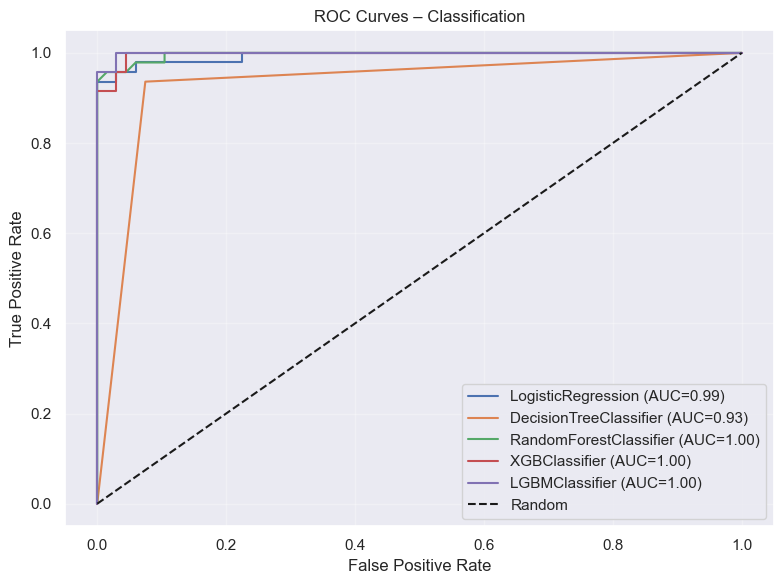

In [220]:
# Roc_Auc_Curve for all models

def plot_roc_curve(y_test, y_prob, label, color):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc:.2f})", color=color)

plt.figure(figsize=(8, 6))

colors = ["C0", "C1", "C2", "C3", "C4"]
for (name, res), c in zip(results_cls.items(), colors):
    plot_roc_curve(y_test, res["y_prob"], name, c)

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Classification")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Regression Models on (California Housing Prices Dataset)

In [221]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set()
import warnings
warnings.filterwarnings("ignore")

In [222]:
# import dataset
data = pd.read_csv('housing.csv')
house = data.copy()

In [223]:
house.info()  # General information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [224]:
house.isnull().sum() # checking for null values in dataset

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [225]:
house.duplicated().sum() # if data contain duplicates, uses house.drop_duplicates(inplace = True)

np.int64(0)

In [226]:
# Handle null values with simple imputer
from sklearn.impute import SimpleImputer
si = SimpleImputer( strategy = 'mean')
house[['total_bedrooms']] = si.fit_transform(house[['total_bedrooms']])

In [227]:
house.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [228]:
# separate x and y values from data set

x = house[['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity']]
y = house['median_house_value']

In [229]:
# Encoding for Categorical data
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [-1])], remainder = 'passthrough')
x =np.array(ct.fit_transform(x))

In [230]:
# split data in to train and test set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y , test_size = 0.2, random_state = 0)

In [238]:
# create models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression 
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score

Regression_models = {
    "LinearRegression" : LinearRegression(),
    "DecisionTreeRegressor" : DecisionTreeRegressor(random_state =0),
    "RandomForestRegressor" : RandomForestRegressor(n_estimators = 100, random_state =0),
    "XGBRegressor" : XGBRegressor(),
    "LGBMRegressor" : LGBMRegressor()
}

In [239]:
# train, predict and collect metrics
results_reg = {}

for name, model in Regression_models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results_reg[name] = {"rmse": rmse, "r2": r2, "mse": mse ,"y_pred": y_pred}

    print(f"{name:<20} -  MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")

LinearRegression     -  MSE: 4718206968.30, RMSE: 68689.21, R²: 0.638
DecisionTreeRegressor -  MSE: 4669494576.40, RMSE: 68333.70, R²: 0.642
RandomForestRegressor -  MSE: 2317041512.46, RMSE: 48135.66, R²: 0.822
XGBRegressor         -  MSE: 2102453094.39, RMSE: 45852.51, R²: 0.839
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001216 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1846
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 12
[LightGBM] [Info] Start training from score 207249.895894
LGBMRegressor        -  MSE: 2162155213.79, RMSE: 46498.98, R²: 0.834


In [240]:
# R2 score for best model
best_name = max(results_reg, key=lambda name: results_reg[name]["r2"])
print(f'{best_name}, - R2: {r2:.3f}, MSE : {mse:.3f}, RMSE : {rmse:.3f}')

XGBRegressor, - R2: 0.834, MSE : 2162155213.789, RMSE : 46498.981
